In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/AER/CPS1988.csv"
df = pd.read_csv(url)

In [2]:
df.head()

,rownames,wage,education,experience,ethnicity,smsa,region,parttime
0,1,354.94,7,45,cauc,yes,northeast,no
1,2,123.46,12,1,cauc,yes,northeast,yes
2,3,370.37,9,9,cauc,yes,northeast,no
3,4,754.94,11,46,cauc,yes,northeast,no
4,5,593.54,12,36,cauc,yes,northeast,no


In [3]:
df.drop(columns = ['rownames'], inplace = True)
df.head()

,wage,education,experience,ethnicity,smsa,region,parttime
0,354.94,7,45,cauc,yes,northeast,no
1,123.46,12,1,cauc,yes,northeast,yes
2,370.37,9,9,cauc,yes,northeast,no
3,754.94,11,46,cauc,yes,northeast,no
4,593.54,12,36,cauc,yes,northeast,no


**Basic Statistics**

| Column Name | Type | Description |
|-------------|------|-------------|
| **wage** | Continuous | Hourly wage of the individual (target variable) |
| **education** | Continuous | Number of years of education completed |
| **experience** | Continuous | Number of years of work experience |
| **ethnicity** | Categorical | Ethnic group of the individual (e.g., cauc = Caucasian) |
| **smsa** | Categorical / Binary | Indicates whether the person lives in a metropolitan area (**yes = urban**, **no = non-urban**) |
| **region** | Categorical | Geographic region where the individual lives (e.g., northeast, south, west, etc.) |
| **parttime** | Categorical / Binary | Employment type (**yes = part-time**, **no = full-time**) |

In [4]:
df.describe()

,wage,education,experience
count,28155.000000,28155.000000,28155.000000
mean,603.726846,13.067874,18.199929
std,453.547350,2.899682,13.079233
min,50.050000,0.000000,-4.000000
25%,308.640000,12.000000,8.000000
50%,522.320000,12.000000,16.000000
75%,783.480000,15.000000,27.000000
max,18777.200000,18.000000,63.000000


In [5]:
df.dtypes

wage          float64
education       int64
experience      int64
ethnicity      object
smsa           object
region         object
parttime       object
dtype: object

In [6]:
df.shape

(28155, 7)

**Missing values**

In [7]:
df.isnull().sum()

wage          0
education     0
experience    0
ethnicity     0
smsa          0
region        0
parttime      0
dtype: int64

## **Understand Target variable(wage)**

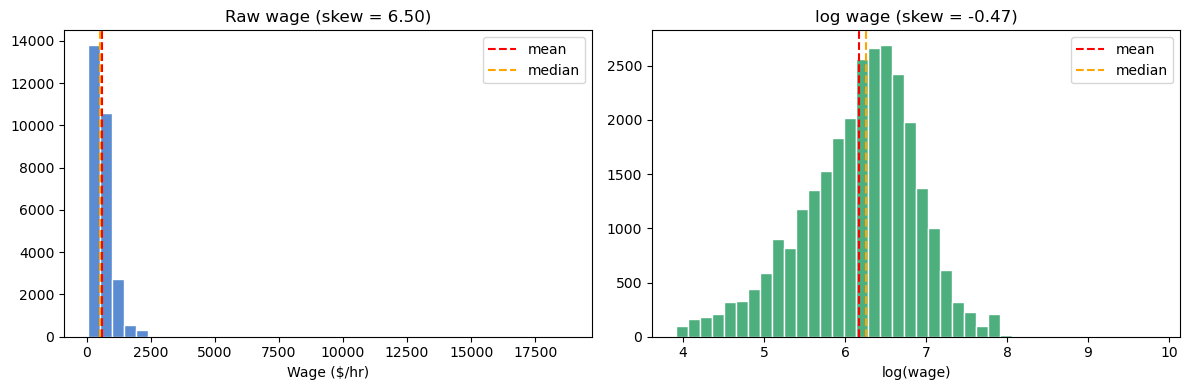

In [8]:
# Raw vs log wage side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw wage
axes[0].hist(df['wage'], bins = 40, color = '#5B8BD0', edgecolor = 'white')
axes[0].set_title(f"Raw wage (skew = {df['wage'].skew():.2f})")
axes[0].set_xlabel('Wage ($/hr)')
axes[0].axvline(df['wage'].mean(), color = 'red', linestyle = '--', label='mean')
axes[0].axvline(df['wage'].median(), color = 'orange', linestyle = '--', label='median')
axes[0].legend()

# Log wage
df['log_wage'] = np.log(df['wage'])
axes[1].hist(df['log_wage'], bins = 40, color = '#4CAF7D', edgecolor = 'white')
axes[1].set_title(f"log wage (skew = {df['log_wage'].skew():.2f})")
axes[1].set_xlabel('log(wage)')
axes[1].axvline(df['log_wage'].mean(), color = 'red', linestyle = '--', label = 'mean')
axes[1].axvline(df['log_wage'].median(), color = 'orange', linestyle = '--', label = 'median')
axes[1].legend()

plt.tight_layout()
plt.show()

| Skew Value | Interpretation |
|------------|----------------|
| skew ≈ 0 | Symmetric / Normal |
| skew > 0 | Right-skewed |
| skew < 0 | Left-skewed |
| skew ≥ 1 or ≤ -1 | Highly skewed |

In [9]:
from scipy import stats

# Normalty test (using sample of 200 - Shapiro needs n < 5000)
stat, p = stats.shapiro(df['log_wage'].sample(200, random_state = 42))
print(f"Shapiro-Wilk on log(wage): p = {p:.4f}")
print("Approximately normal!" if p > 0.05 else "Still not normal")

Shapiro-Wilk on log(wage): p = 0.0022
Still not normal


## Shapiro–Wilk Normality Test

The **Shapiro–Wilk test** is used to statistically check whether a variable follows a normal distribution.

### Hypotheses
- **H₀:** Data is normally distributed
- **H₁:** Data is not normally distributed

### Decision Rule
- **p > 0.05** → Approximately normal ✓
- **p ≤ 0.05** → Not normal ✗

### Why did `log_wage` fail?
Although the log transformation reduced skewness and improved symmetry, the Shapiro–Wilk test still rejected normality because it is highly sensitive to small deviations, especially in the tails. Real-world wage data is rarely perfectly normal.

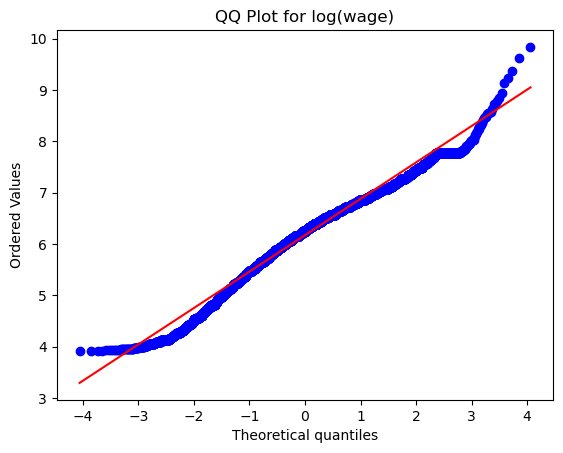

In [10]:
# QQ - plot

stats.probplot(df['log_wage'], dist = 'norm', plot = plt)
plt.title('QQ Plot for log(wage)')
plt.show()

## Q-Q Plot Interpretation

A **Q-Q (Quantile–Quantile) plot** compares the data distribution with a theoretical normal distribution.

- If points lie close to the straight line → Data is approximately normal ✓
- If points deviate from the line → Data is not perfectly normal ✗

For `log_wage`, most points follow the line, while slight deviations appear in the tails. This indicates **approximate normality with minor tail deviations**, making it suitable for further analysis.

## Split by ethnicity

In [11]:
df['ethnicity'].unique()

array(['cauc', 'afam'], dtype=object)

In [12]:
cauc = df[df['ethnicity'] == 'cauc']['log_wage']
afam = df[df['ethnicity'] == 'afam']['log_wage']

gap_log = cauc.mean() - afam.mean()
gap_pct = (np.exp(gap_log) - 1) * 100

print(f"Caucasian mean log wage : {cauc.mean():.3f}")
print(f"African-Am mean log wage: {afam.mean():.3f}")
print(f"Gap (log points)        : {gap_log:.3f}")
print(f"Gap (percentage)        : {gap_pct:.2f}%")

Caucasian mean log wage : 6.195
African-Am mean log wage: 5.884
Gap (log points)        : 0.312
Gap (percentage)        : 36.58%


There is a correlation between ethnicity and wages in this sample. Caucasian men earn 36.58% more on average. However, this is an unconditional gap — it does not account for differences in education, experience, region, or employment type. Whether ethnicity has an independent effect on wages will be determined after controlling for these factors in the regression."

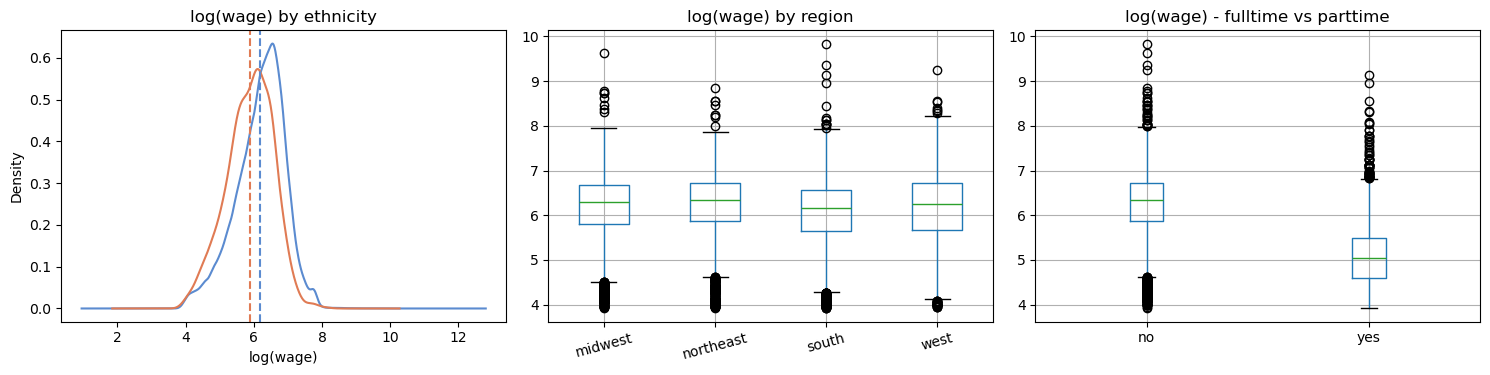

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ethnicity KDE
cauc.plot(kind = 'kde', ax = axes[0], color = '#5B8BD0', label = 'Caucasian')
afam.plot(kind = 'kde', ax = axes[0], color = '#E07B54', label = 'African-Am')
axes[0].axvline(cauc.mean(), color = '#5B8BD0', linestyle = '--', linewidth = 1.5)
axes[0].axvline(afam.mean(), color = '#E07B54', linestyle = '--', linewidth = 1.5)
axes[0].set_title('log(wage) by ethnicity')
axes[0].set_xlabel('log(wage)')

#Region boxplot
df.boxplot(column = 'log_wage', by = 'region', ax = axes[1])
axes[1].set_title('log(wage) by region')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.xticks(rotation=15)

# Parttime boxplot
df.boxplot(column = 'log_wage', by = 'parttime', ax=axes[2])
axes[2].set_title('log(wage) - fulltime vs parttime')
axes[2].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

log_wage      1.000
education     0.308
experience    0.241
smsa          0.114
ethnicity    -0.118
parttime     -0.462
Name: log_wage, dtype: float64


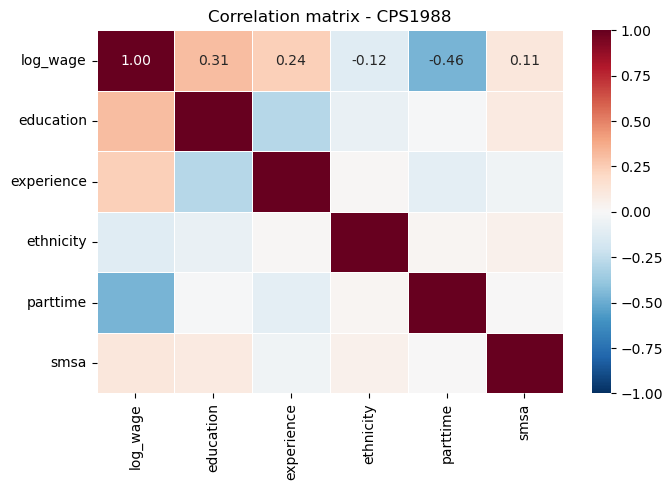

In [21]:
df_corr = df.copy()
df_corr['ethnicity'] = (df['ethnicity'] == 'afam').astype(int)
df_corr['parttime']  = (df['parttime'] == 'yes').astype(int)
df_corr['smsa']      = (df['smsa'] == 'yes').astype(int)

num_cols = ['log_wage', 'education', 'experience', 'ethnicity', 'parttime', 'smsa']
corr = df_corr[num_cols].corr()

print(corr['log_wage'].sort_values(ascending = False).round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center = 0, vmin = -1, vmax = 1, linewidths = 0.5)
plt.title('Correlation matrix - CPS1988')
plt.tight_layout()
plt.show()

## Correlation with `log_wage`

- **Parttime** shows the strongest negative correlation with `log_wage` (**-0.462**), indicating that part-time work is associated with lower wages.

- **Education** shows the strongest positive correlation (**+0.308**), suggesting that higher education is associated with higher wages.

- **Ethnicity** shows a relatively small negative correlation (**-0.118**). However, correlation alone can be misleading — the unconditional wage gap is **36.58%**.

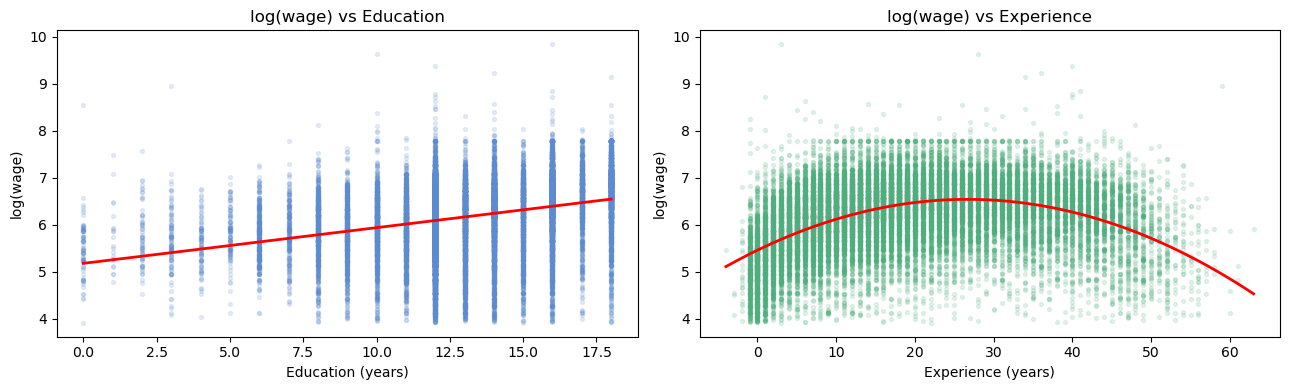

In [22]:
## Scatter plots --- linearity check

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Education vs log wage
axes[0].scatter(df['education'], df['log_wage'], alpha = 0.15, s = 8, color = '#5B8BD0')

# Overlay a trend line
m, b = np.polyfit(df['education'], df['log_wage'], 1)
x_line = np.linspace(df['education'].min(), df['education'].max(), 10)
axes[0].plot(x_line, m*x_line + b, color = 'red', linewidth = 2)
axes[0].set_xlabel('Education (years)')
axes[0].set_ylabel('log(wage)')
axes[0].set_title('log(wage) vs Education')

# Experience vs log wage
axes[1].scatter(df['experience'], df['log_wage'], alpha = 0.15, s=8, color='#4CAF7D')
# Overlay Quadratic fit
z = np.polyfit(df['experience'], df['log_wage'], 2)
x_line = np.linspace(df['experience'].min(), df['experience'].max(), 100)
axes[1].plot(x_line, np.polyval(z, x_line), color='red', linewidth = 2)
axes[1].set_xlabel('Experience (years)')
axes[1].set_ylabel('log(wage)')
axes[1].set_title('log(wage) vs Experience')

plt.tight_layout()
plt.show()

## Education vs `log_wage`

The scatter plot shows a clear upward linear trend between education and `log_wage`.

This suggests a strong positive linear relationship, making education a suitable predictor for linear regression.


## Experience vs `log_wage`

The scatter plot shows a curved, inverted U-shaped pattern.

This indicates a nonlinear relationship — wages increase with experience initially, but the effect weakens later.

An **experience²** term will be required in later modeling.

Correlation between education & experience: -0.287


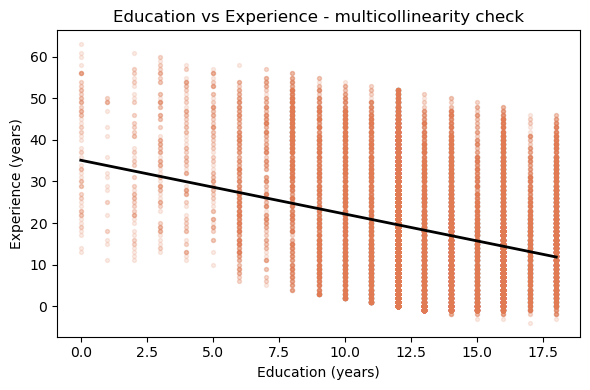

In [24]:
# Education vs Experience - multicollinearity check

plt.figure(figsize=(6, 4))
plt.scatter(df['education'], df['experience'], alpha = 0.15, s= 8, color = '#E07B54')
m, b = np.polyfit(df['education'], df['experience'], 1)
x_line = np.linspace(df['education'].min(), df['education'].max(), 100)
plt.plot(x_line, m*x_line + b, color = 'black', linewidth= 2)
print(f"Correlation between education & experience: {df['education'].corr(df['experience']):.3f}")
plt.xlabel('Education (years)')
plt.ylabel('Experience (years)')
plt.title('Education vs Experience - multicollinearity check')
plt.tight_layout()
plt.show()

## Education vs Experience

Education and experience show a negative relationship.
This suggests that individuals with more years of education typically have fewer years of work experience.
This may create **multicollinearity risk**.